In [1]:
import numpy as np
import pandas as pd
import os

from pathlib import Path

def resolve_data_dir() -> Path:
    """Locate the dataset locally or on Kaggle."""
    candidates = [
        Path("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge"),
        Path("../data"),
        Path("data"),
        Path("."),
    ]
    for path in candidates:
        if (path / "train.csv").exists():
            return path
    raise FileNotFoundError(
        "Could not find train.csv. Place the CSVs in ../data (from notebooks/) "
        "or keep the default Kaggle input path."
    )

DATA_DIR = resolve_data_dir()
print("Using data directory:", DATA_DIR.resolve())


/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/metadata.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv


In [2]:
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
ss = pd.read_csv(DATA_DIR / "sample_submission.csv")


/tmp/ipykernel_16/3205134266.py:1: DtypeWarning: Columns (38,39) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv")


In [3]:
print(f"Train Shape : {train.shape}")
print(f"Test Shape  : {test.shape}")
print(f"Sample Submission Shape: {ss.shape}")

Train Shape : (138701, 50)
Test Shape  : (15000, 49)
Sample Submission Shape: (15000, 2)


In [4]:
train.head()

,TransactionID,TargetValue,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,...,col20,col21,col22,col23,col24,col25,col27,col28,col29,col30
0,1139309,57000.0,117665,88,ACH138,GTX,1997,4640.0,Low,2005-03-26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139316,26500.0,1001282,4616,ACH138,GTX,2005,508.0,Low,2009-12-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1139317,21000.0,772709,1948,ACH138,GTX,1994,11540.0,High,2005-08-26,...,Steel,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN
3,1139322,27000.0,902010,3550,ACH138,GTX,2002,4883.0,High,2006-11-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139333,21500.0,1036259,36014,ACH138,GTX,2009,302.0,Low,2010-08-27,...,Rubber,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN


In [5]:
test.head()

,TransactionID,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,Spec_FullDescriptor,...,col20,col21,col22,col23,col24,col25,col27,col28,col29,col30
0,1139307,999097,3168,ACH138,GTX,2005,68.0,Low,2007-11-16,521D,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139419,1018084,1344,ACH138,GTX,1999,10466.0,Medium,2007-06-01,345BL,...,Steel,None or Unspecified,"15' 9""",None or Unspecified,Yes,Double,NaN,NaN,NaN,NaN
2,1139482,1048712,2808,ACH138,GTX,2001,3817.0,Low,2012-06-16,EX120-5,...,Steel,None or Unspecified,None or Unspecified,Hydraulic,None or Unspecified,Double,NaN,NaN,NaN,NaN
3,1139522,697537,1089,ACH138,GTX,2006,1498.0,Medium,2010-08-27,304CR,...,Rubber,16 inch,None or Unspecified,Manual,Yes,Double,NaN,NaN,NaN,NaN
4,1139684,1048082,16781,ACH138,GTX,2009,22.0,Low,2010-07-09,L2800D,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138701 entries, 0 to 138700
Data columns (total 50 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   TransactionID              138701 non-null  int64  
 1   TargetValue                138701 non-null  float64
 2   AssetID                    138701 non-null  int64  
 3   ProductConfigID            138701 non-null  int64  
 4   DataOriginCode             138701 non-null  object 
 5   VendorPartnerID            138701 non-null  object 
 6   ManufactureYear            138701 non-null  int64  
 7   OperationalHoursMeter      82058 non-null   float64
 8   UtilizationTier            50475 non-null   object 
 9   TransactionDate            138701 non-null  object 
 10  Spec_FullDescriptor        138701 non-null  object 
 11  Spec_BaseClass             138701 non-null  object 
 12  Spec_SubClass              101716 non-null  object 
 13  Spec_ReleaseSeries         32

In [7]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 49 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   TransactionID              15000 non-null  int64  
 1   AssetID                    15000 non-null  int64  
 2   ProductConfigID            15000 non-null  int64  
 3   DataOriginCode             15000 non-null  object 
 4   VendorPartnerID            15000 non-null  object 
 5   ManufactureYear            15000 non-null  int64  
 6   OperationalHoursMeter      8809 non-null   float64
 7   UtilizationTier            5356 non-null   object 
 8   TransactionDate            15000 non-null  object 
 9   Spec_FullDescriptor        15000 non-null  object 
 10  Spec_BaseClass             15000 non-null  object 
 11  Spec_SubClass              11006 non-null  object 
 12  Spec_ReleaseSeries         3505 non-null   object 
 13  Spec_VariantModifier       5609 non-null   obj

# **Statistical Summary**

In [8]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
TransactionID,138701.0,2.186276e+06,1.128497e+06,1139309.0,1465754.0,1751884.0,2372139.0,6333410.0
TargetValue,138701.0,4.152187e+04,2.636113e+04,7500.0,20500.0,35000.0,57000.0,142000.0
AssetID,138701.0,1.204814e+06,5.287376e+05,8.0,1007930.0,1246956.0,1495817.0,2478476.0
ProductConfigID,138701.0,7.286422e+03,7.542422e+03,39.0,1693.0,3852.0,11873.0,37209.0
ManufactureYear,138701.0,1.891641e+03,3.069920e+02,1001.0,1990.0,1998.0,2004.0,2015.0
OperationalHoursMeter,82058.0,4.553719e+03,2.792204e+04,0.0,0.0,1620.0,5001.0,1729600.0


In [9]:
train.describe(include="object").T

,count,unique,top,freq
DataOriginCode,138701,6,ADI149,59541
VendorPartnerID,138701,31,UJF,67828
UtilizationTier,50475,3,Medium,24588
TransactionDate,138701,3676,2010-02-16,1159
Spec_FullDescriptor,138701,3505,140G,3751
Spec_BaseClass,138701,1249,12,5702
Spec_SubClass,101716,147,G,17381
Spec_ReleaseSeries,32896,113,II,8425
Spec_VariantModifier,52332,132,L,14496
AssetScaleFactor,97491,6,Large / Medium,39222


# **Missing Value Analysis**

In [10]:
missing = pd.DataFrame({
    "Missing Values": train.isnull().sum(),
    "Missing Percentage": (train.isnull().sum() / len(train)) * 100
})

missing = missing.sort_values("Missing Percentage", ascending=False)

missing.head(20)

,Missing Values,Missing Percentage
col19,138635,99.952416
col18,138635,99.952416
col5,128320,92.515555
col4,128320,92.515555
col27,123742,89.214930
col28,123742,89.214930
col29,119829,86.393753
col30,119829,86.393753
col13,115296,83.125572
col14,115296,83.125572


# **Handling Missing Values**

In [11]:
train_df = train.copy()
test_df = test.copy()

train_df.drop(columns=["col18", "col19"], inplace=True)
test_df.drop(columns=["col18", "col19"], inplace=True)

print(train_df.shape)
print(test_df.shape)

(138701, 48)
(15000, 47)


# **Feature Engineering**

In [12]:
train_df["TransactionDate"] = pd.to_datetime(train_df["TransactionDate"])
test_df["TransactionDate"] = pd.to_datetime(test_df["TransactionDate"])

In [13]:
# extracting transaction year
train_df["TransactionYear"] = train_df["TransactionDate"].dt.year
test_df["TransactionYear"] = test_df["TransactionDate"].dt.year

In [14]:
# extracting transaction month
train_df["TransactionMonth"] = train_df["TransactionDate"].dt.month
test_df["TransactionMonth"] = test_df["TransactionDate"].dt.month

In [15]:
# extracting transaction quarter
train_df["TransactionQuarter"] = train_df["TransactionDate"].dt.quarter
test_df["TransactionQuarter"] = test_df["TransactionDate"].dt.quarter

In [16]:
# creating machine age
train_df["MachineAge"] = (train_df["TransactionYear"] - train_df["ManufactureYear"])
test_df["MachineAge"] = (test_df["TransactionYear"] - test_df["ManufactureYear"])

In [17]:
# checking negative ages
print("Negative ages in train:", (train_df["MachineAge"] < 0).sum())
print("Negative ages in test :", (test_df["MachineAge"] < 0).sum())

Negative ages in train: 7
Negative ages in test : 2


In [18]:
# handling invalid machine ages
train_df.loc[train_df["MachineAge"] < 0, "MachineAge"] = 0
test_df.loc[test_df["MachineAge"] < 0, "MachineAge"] = 0

In [19]:
train_df.drop(columns=["TransactionDate"], inplace=True)
test_df.drop(columns=["TransactionDate"], inplace=True)

In [20]:
X = train_df.drop("TargetValue", axis=1)

y = np.log1p(train_df["TargetValue"])

In [21]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import root_mean_squared_log_error

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

In [22]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [23]:
numeric_features = X_train.select_dtypes(include=["int64","float64"]).columns

categorical_features = X_train.select_dtypes(include=["object"]).columns

In [24]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

In [25]:
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value",
                               unknown_value=-1))
])

In [26]:
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [27]:
X_train = preprocessor.fit_transform(X_train)

X_valid = preprocessor.transform(X_valid)

X_test = preprocessor.transform(test_df)

In [28]:
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train,y_train)

rf_pred = np.expm1(rf.predict(X_valid))

rf_score = root_mean_squared_log_error(
    np.expm1(y_valid),
    rf_pred
)

print(rf_score)

0.22843428960965345


In [29]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    random_state=42
)

xgb.fit(X_train,y_train)

xgb_pred = np.expm1(xgb.predict(X_valid))

xgb_score = root_mean_squared_log_error(
    np.expm1(y_valid),
    xgb_pred
)

print(xgb_score)

0.2367475730232636


In [30]:
lgb = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

lgb.fit(X_train,y_train)

lgb_pred = np.expm1(lgb.predict(X_valid))

lgb_score = root_mean_squared_log_error(
    np.expm1(y_valid),
    lgb_pred
)

print(lgb_score)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.034186 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2281
[LightGBM] [Info] Number of data points in the train set: 110960, number of used features: 47
[LightGBM] [Info] Start training from score 10.424734
0.25365466576637774


In [31]:
comparison = pd.DataFrame({
    "Model":["Random Forest","XGBoost","LightGBM"],
    "RMSLE":[rf_score,xgb_score,lgb_score]
})

comparison.sort_values("RMSLE")

,Model,RMSLE
0,Random Forest,0.228434
1,XGBoost,0.236748
2,LightGBM,0.253655


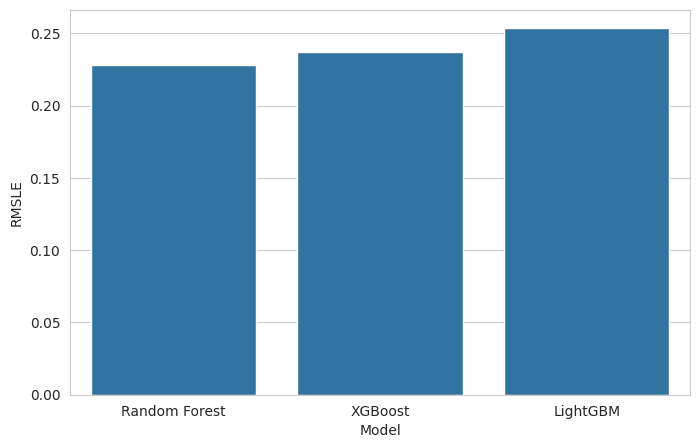

In [32]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="RMSLE"
)

plt.show()

In [33]:
best_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

In [34]:
X_full = train_df.drop("TargetValue",axis=1)

y_full = np.log1p(train_df["TargetValue"])

In [35]:
X_full = preprocessor.fit_transform(X_full)

X_test = preprocessor.transform(test_df)

In [36]:
best_model.fit(X_full,y_full)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.028246 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2299
[LightGBM] [Info] Number of data points in the train set: 138701, number of used features: 47
[LightGBM] [Info] Start training from score 10.424111


LGBMRegressor(learning_rate=0.05, n_estimators=300, random_state=42)

In [37]:
prediction = np.expm1(
    best_model.predict(X_test)
)

In [38]:
submission = ss.copy()

submission["TargetValue"] = prediction

submission.to_csv(
    "submission.csv",
    index=False
)

submission.head()

,TransactionID,TargetValue
0,1139307,70268.201466
1,1139419,65199.476742
2,1139482,26382.230912
3,1139522,23649.787566
4,1139684,14166.159431


In [39]:
import sys
sys.exit()

SystemExit: 

# Milestone 1

**Question 1 (MCQ):** Dataset Dimensions 

In [ ]:
print("Train dataset rows:", train.shape[0])
print("Test dataset rows:", test.shape[0])

**Question 2 (MCQ):** Target Variable Identification 

In [ ]:
set(train.columns) - set(test.columns)

**Question 3 (Numeric):** Feature Data Types

In [ ]:
print(train.select_dtypes(include='number').shape[1])

**Question 4 (MSQ):** Extremely Sparse Columns 

In [ ]:
missing_pct = train.isnull().mean() * 100

sparse_cols = missing_pct[missing_pct > 90]

print(f"Number of columns with >90% missing values: {len(sparse_cols)}")
print(sparse_cols.sort_values(ascending=False))

**Question 5 (Numeric):** Missing Operational Metrics 

In [ ]:
missing_count = train['OperationalHoursMeter'].isna().sum()
total_rows = len(train)

missing_pct = (missing_count / total_rows) * 100

print("Missing values:", missing_count)
print("Percentage missing:", round(missing_pct, 2), "%")

**Question 6 (MCQ):** Target Value Distribution 

In [ ]:
median_price = train['TargetValue'].median()
print(f"Median TargetValue: {median_price:,.0f}")

**Question 7 (Numeric):** Manufacture Year Anomaly

In [ ]:
train['ManufactureYear'].mode()

**Question 8 (MCQ):** Time Span of Transactions 

In [ ]:
train['TransactionDate'] = pd.to_datetime(train['TransactionDate'])

print(train['TransactionDate'].min())

**Question 9 (Numeric):** High Cardinality Identification

In [ ]:
train['Spec_BaseClass'].nunique()

**Question 10 (MCQ):** Geographical Volume 

In [ ]:
train['RegionCode'].value_counts()

**Question 11 (Numeric):** Regional Pricing Insights 

In [ ]:
train[train['RegionCode'] == 'Florida']['TargetValue'].mean()

**Question 12 (MCQ):** Asset Utilization 

In [ ]:
train['UtilizationTier'].value_counts()

**Question 13 (MCQ):** Operational Correlation

In [ ]:
train[['TargetValue', 'OperationalHoursMeter']].corr(method='pearson')

**Question 14 (MCQ):** Primary Equipment Types

In [ ]:
train['FunctionalClassification'].mode()[0]

# Milestone 2

**Question 1**

In [ ]:
train["TransactionDate"] = pd.to_datetime(train["TransactionDate"])

In [ ]:
train["TransactionYear"] = train["TransactionDate"].dt.year
train["TransactionQuarter"] = train["TransactionDate"].dt.quarter

In [ ]:
train["AssetAge"] = train["TransactionYear"] - train["ManufactureYear"]

In [ ]:
train["DescriptorLength"] = (
    train["Spec_FullDescriptor"]
    .fillna("")
    .astype(str)
    .str.len()
)

In [ ]:
train["HasOperationalHours"] = train["OperationalHoursMeter"].notna().astype(int)
train["HasVariantModifier"] = train["Spec_VariantModifier"].notna().astype(int)

In [ ]:
most_frequent_asset_age = train["AssetAge"].mode()[0]
print("Most frequent AssetAge:", most_frequent_asset_age)

**Question 2**

In [ ]:
quarter_avg = train.groupby("TransactionQuarter")["TargetValue"].mean()
print("Average TargetValue by Quarter:")
print(quarter_avg.idxmax())

**Question 3**

In [ ]:
print("Maximum DescriptorLength:", train["DescriptorLength"].max())

**Question 4**

In [ ]:
count_operational = train["HasOperationalHours"].sum()
print("HasOperationalHours = 1:", count_operational)

**Question 5**

In [ ]:
variant_percent = train["HasVariantModifier"].mean() * 100
print("Percentage with Variant Info: {:.2f}%".format(variant_percent))

**Question 6**

In [ ]:
mean_year = train["ManufactureYear"].mean()
print("Mean ManufactureYear: {:.2f}".format(mean_year))

**Question 7**

In [ ]:
encoded = pd.get_dummies(
    train,
    columns=["RegionCode", "CabinType", "UtilizationTier"],
    drop_first=True
)

region_cols = pd.get_dummies(train["RegionCode"], drop_first=True).shape[1]
cabin_cols = pd.get_dummies(train["CabinType"], drop_first=True).shape[1]
util_cols = pd.get_dummies(train["UtilizationTier"], drop_first=True).shape[1]

total_encoded = region_cols + cabin_cols + util_cols

In [ ]:
print("Encoded Columns Created:", total_encoded)

**Question 8**

In [ ]:
numeric_cols = train.select_dtypes(include=np.number)
corr = numeric_cols.corr(method="pearson")
target_corr = corr["TargetValue"].abs().sort_values(ascending=False)

In [ ]:
print(target_corr)

**Question 9**

In [ ]:
features = ["ManufactureYear", "OperationalHoursMeter", "AssetAge"]

X = train[features].copy()
y = train["TargetValue"]

In [ ]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="mean")
X = imputer.fit_transform(X)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [ ]:
print("Training Shape:", X_train.shape)

**Question 10**

In [ ]:
print("Validation Shape:", X_valid.shape)

**Question 11**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X2 = train[["ManufactureYear", "AssetAge"]]

X2 = SimpleImputer(strategy="mean").fit_transform(X2)
X2 = StandardScaler().fit_transform(X2)

X_train2, X_valid2, y_train2, y_valid2 = train_test_split(
    X2,
    y,
    test_size=0.20,
    random_state=42
)

model = LinearRegression()
model.fit(X_train2, y_train2)

pred = model.predict(X_valid2)

r2 = r2_score(y_valid2, pred)

print("R2 Score:", r2)

# Milestone 3

**Question 1**

In [ ]:
train_df = train.copy()

In [ ]:
train_df["TransactionDate"] = pd.to_datetime(train_df["TransactionDate"])

train_df["SaleYear"] = train_df["TransactionDate"].dt.year

mode_sale_year = train_df["SaleYear"].mode()[0]

print(mode_sale_year)

**Question 2**

In [ ]:
train_df["ManufactureYear"] = train_df["ManufactureYear"].replace([1000, 1001], np.nan)

train_df["AssetAge"] = train_df["SaleYear"] - train_df["ManufactureYear"]

median_age = train_df["AssetAge"].median()

print(median_age)

**Question 3**

In [ ]:
missing_fraction = train_df.isna().mean()

cols_to_drop = missing_fraction[missing_fraction > 0.80]

print("Columns to drop:", len(cols_to_drop))
print(cols_to_drop.index.tolist())

**Question 4**

Median

**Question 5**

In [ ]:
filled = train_df["CabinType"].fillna("Missing")

missing_count = (filled == "Missing").sum()

print(missing_count)

**Question 6**

In [ ]:
train_df["HoursPerYear"] = (
    train_df["OperationalHoursMeter"] /
    train_df["AssetAge"]
)

train_df["HoursPerYear"] = train_df["HoursPerYear"].replace([np.inf, -np.inf], np.nan)

median_hours = train_df["HoursPerYear"].median()

print(median_hours)

**Question 7**

The categorical feature has very high cardinality

**Question 8**

In [ ]:
from sklearn.model_selection import train_test_split

df = train.copy()

X = df.drop(columns=["TargetValue"])
y = df["TargetValue"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape[0])

**Question 9**

In [ ]:
import numpy as np

df = train.copy()

y_log = np.log1p(df["TargetValue"])

print(y_log.std())

**Question 10**

Before applying any scalers, target encoders, or median imputations.

**Question 11**

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

df = train.copy()

enc = OrdinalEncoder()

encoded = enc.fit_transform(df[["UtilizationTier"]])

print(len(enc.categories_[0]))

**Question 12**

Gradient Boosted Trees (LightGBM/XGBoost)

**Question 13**

The total number of individual decision trees built in the ensemble.

**Question 14**

The model used that specific feature frequently to make highly accurate splits in the decision trees, meaning it strongly influences the target prediction.

**Question 15**

It automatically halts training if the validation score stops improving, preventing the model from overfitting to the training data.